In [34]:
""" Problem 7.5.1 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_45508\760091608.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,-20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_45508\760091608.py:35: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


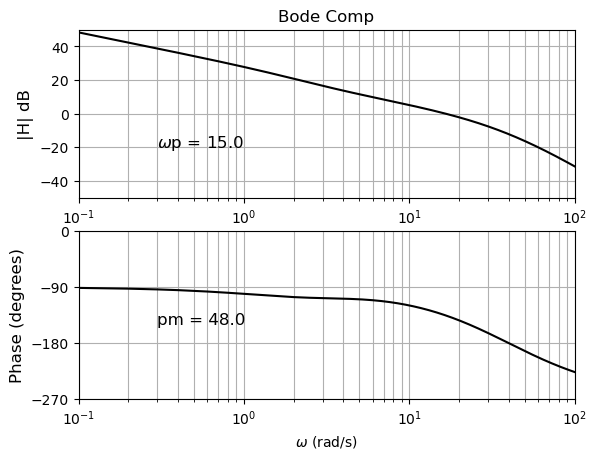

In [42]:
K = 1300
n1 = [ 0, 0, 0, 24]
d1 = [1, 8, 12, 0]

n2 = [0, 1, 8, 16]
d2 = [0, 1, 80, 1600]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -50, 50])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,-20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -270,0])
plt.yticks([-270,-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

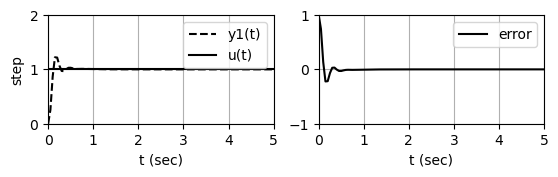

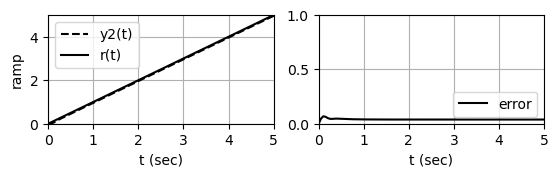

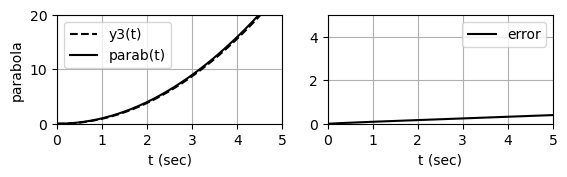

In [38]:
""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,5,-1,1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,0,1])
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.axis([0,5,0,20])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()
plt.show()